# UrbanEV station-level EDA

Notebook này đánh giá thủ công UrbanEV **trước** preprocessing, training và mọi quyết định hiệu chỉnh `station_status`. Notebook chỉ đọc archive gốc và ghi artifact EDA; không sửa dữ liệu runtime.

Câu hỏi chính: chuỗi có đúng nhịp 5 phút không; capacity có ổn định và khớp metadata không; fast/slow có khớp tổng không; occupancy có đủ biến thiên và pattern hợp lý không; trạm nào cần giữ, loại hoặc điều tra thêm?

> Các ngưỡng chỉ dùng để gắn cờ hỗ trợ review. UrbanEV không cung cấp ground truth cho queue hoặc wait time.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import json
import random

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 1. Cấu hình

Mặc định dùng mẫu cố định để kiểm tra nhanh. Sau khi sample run ổn, đổi `FULL_SCAN = True`. Full scan đọc tuần tự 1.429 file và không giữ toàn bộ time series trong RAM.

In [ ]:
FULL_SCAN = False
SAMPLE_STATIONS = 30
RANDOM_SEED = 42
MAX_PLOT_ROWS_PER_STATION = 2_000
EXPECTED_INTERVAL_MIN = 5
MAX_MISSING_INTERVAL_RATE = 0.01  # chỉ để gắn cờ
MIN_OCCUPANCY_STD = 0.01  # chỉ để gắn cờ

def find_repo_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "data_platform/data/ml/urbanev/source_manifest.json").is_file():
            return candidate
    raise FileNotFoundError("Không tìm thấy repository root")

ROOT = find_repo_root(Path.cwd())
ARCHIVE = ROOT / "data_platform/data/ml/urbanev/raw/UrbanEVDataset.zip"
OUTPUT_DIR = ROOT / "data_platform/data/ml/urbanev/eda"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
if not ARCHIVE.is_file():
    raise FileNotFoundError(f"Thiếu UrbanEV archive: {ARCHIVE}")
print(f"Archive: {ARCHIVE}")
print(f"Mode: {'FULL' if FULL_SCAN else f'SAMPLE ({SAMPLE_STATIONS} stations)'}")

## 2. Inventory, metadata và schema

EDA dùng `station-processed`; metadata station dùng để kiểm tra chéo capacity. Chỉ mở raw chi tiết khi một trạm bị gắn cờ.

In [3]:
PROCESSED_PREFIX = "UrbanEVDataset/20220901-20230228_station-processed/"
REQUIRED_COLUMNS = ["time", "busy", "idle", "fast_busy", "fast_idle", "slow_busy", "slow_idle", "duration", "volume"]

with ZipFile(ARCHIVE) as archive:
    all_members = archive.namelist()
    station_members = sorted(
        (name for name in all_members if name.startswith(PROCESSED_PREFIX) and name.endswith(".csv") and Path(name).stem.isdigit()),
        key=lambda name: int(Path(name).stem),
    )
    station_info_member = next(name for name in all_members if name.endswith("station_information.csv"))
    with archive.open(station_info_member) as source:
        station_info = pd.read_csv(source, dtype={"station_id": "string", "TAZID": "string"})
    with archive.open(station_members[0]) as source:
        schema_sample = pd.read_csv(source, nrows=5)

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(schema_sample.columns))
if missing_columns:
    raise ValueError(f"Thiếu cột bắt buộc: {missing_columns}")
print(f"Processed station files: {len(station_members):,}")
print(f"Station metadata rows: {len(station_info):,}")
display(station_info.head())
display(station_info.describe(include="all").T)
display(schema_sample)

Processed station files: 1,423
Station metadata rows: 1,682


,station_id,longitude,latitude,slow_count,fast_count,charge_count,TAZID
0,1001,113.784724,22.714121,20,0,20,559
1,1002,113.785002,22.725900,22,0,22,558
2,1003,113.787971,22.735538,6,0,6,558
3,1004,113.788126,22.693449,6,5,11,596
4,1005,113.788126,22.693449,6,5,11,596


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
station_id,1682,1682,1001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,1682.0,NaN,NaN,NaN,114.050417,0.136346,113.784724,113.9337,114.050909,114.127922,114.516991
latitude,1682.0,NaN,NaN,NaN,22.607558,0.077078,22.46557,22.544244,22.584338,22.669594,22.818918
slow_count,1682.0,NaN,NaN,NaN,12.583234,13.915416,0.0,5.0,9.0,14.75,108.0
fast_count,1682.0,NaN,NaN,NaN,2.159929,9.665924,0.0,0.0,0.0,0.0,96.0
charge_count,1682.0,NaN,NaN,NaN,14.743163,15.505426,1.0,6.0,10.0,18.0,108.0
TAZID,1682,331,1011,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,time,busy,idle,s_price,e_price,fast_busy,fast_idle,slow_busy,slow_idle,duration,volume
0,2022-09-01 00:00:00,4.0,16.0,0.47,1.2,0.0,0.0,4.0,16.0,0.000000,0.000000
1,2022-09-01 00:05:00,4.0,16.0,0.47,1.2,0.0,0.0,4.0,16.0,0.000000,0.000000
2,2022-09-01 00:10:00,4.0,16.0,0.47,1.2,0.0,0.0,4.0,16.0,0.000000,0.000000
3,2022-09-01 00:15:00,8.0,12.0,0.47,1.2,0.0,0.0,8.0,12.0,0.083333,0.583333
4,2022-09-01 00:20:00,6.0,14.0,0.47,1.2,0.0,0.0,6.0,14.0,0.083333,0.583333


## 3. Quét chất lượng theo trạm

Mỗi file được tổng hợp riêng. Chỉ một mẫu nhỏ occupancy theo trạm được giữ cho biểu đồ.

In [4]:
NUMERIC_COLUMNS = [column for column in REQUIRED_COLUMNS if column != "time"]

def inspect_station(archive: ZipFile, member: str):
    station_id = Path(member).stem
    with archive.open(member) as source:
        frame = pd.read_csv(source, usecols=REQUIRED_COLUMNS)
    frame["time"] = pd.to_datetime(frame["time"], errors="coerce")
    for column in NUMERIC_COLUMNS:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    valid_times = frame["time"].dropna()
    unique_times = valid_times.drop_duplicates().sort_values()
    deltas_min = unique_times.diff().dropna().dt.total_seconds().div(60)
    gap_mask = deltas_min > EXPECTED_INTERVAL_MIN
    missing_intervals = ((deltas_min[gap_mask] / EXPECTED_INTERVAL_MIN).round() - 1).clip(lower=0).sum()
    total_ports = frame["busy"] + frame["idle"]
    occupancy = frame["busy"].div(total_ports.where(total_ports > 0))
    expected_rows = (
        int((unique_times.iloc[-1] - unique_times.iloc[0]).total_seconds() / 60 / EXPECTED_INTERVAL_MIN) + 1
        if len(unique_times) >= 2 else len(unique_times)
    )
    capacity_values = total_ports.dropna()
    fast_slow_busy = frame["fast_busy"] + frame["slow_busy"]
    fast_slow_idle = frame["fast_idle"] + frame["slow_idle"]
    busy_mismatch = frame["busy"].notna() & fast_slow_busy.notna() & ((frame["busy"] - fast_slow_busy).abs() > 1e-9)
    idle_mismatch = frame["idle"].notna() & fast_slow_idle.notna() & ((frame["idle"] - fast_slow_idle).abs() > 1e-9)
    sample_step = max(1, len(frame) // MAX_PLOT_ROWS_PER_STATION)
    plot_sample = pd.DataFrame({
        "station_id": station_id, "time": frame["time"].iloc[::sample_step],
        "occupancy_ratio": occupancy.iloc[::sample_step],
    }).dropna()
    summary = {
        "station_id": station_id, "row_count": len(frame),
        "start_time": unique_times.iloc[0] if len(unique_times) else pd.NaT,
        "end_time": unique_times.iloc[-1] if len(unique_times) else pd.NaT,
        "expected_rows_in_observed_range": expected_rows,
        "coverage_ratio": len(unique_times) / expected_rows if expected_rows else 0.0,
        "missing_timestamp_rows": int(frame["time"].isna().sum()),
        "duplicate_timestamp_rows": int(valid_times.duplicated(keep=False).sum()),
        "out_of_order_steps": int((valid_times.diff().dropna() < pd.Timedelta(0)).sum()),
        "non_5min_steps": int((deltas_min != EXPECTED_INTERVAL_MIN).sum()),
        "gap_count": int(gap_mask.sum()), "missing_intervals": int(missing_intervals),
        "missing_core_rows": int(frame[["busy", "idle"]].isna().any(axis=1).sum()),
        "negative_busy_rows": int((frame["busy"] < 0).sum()),
        "negative_idle_rows": int((frame["idle"] < 0).sum()),
        "nonpositive_capacity_rows": int((total_ports <= 0).sum()),
        "capacity_min": capacity_values.min() if len(capacity_values) else float("nan"),
        "capacity_max": capacity_values.max() if len(capacity_values) else float("nan"),
        "capacity_unique_count": int(capacity_values.nunique()),
        "busy_fast_slow_mismatch_rows": int(busy_mismatch.sum()),
        "idle_fast_slow_mismatch_rows": int(idle_mismatch.sum()),
        "occupancy_mean": occupancy.mean(), "occupancy_std": occupancy.std(),
        "occupancy_p05": occupancy.quantile(0.05), "occupancy_p50": occupancy.quantile(0.50),
        "occupancy_p95": occupancy.quantile(0.95), "occupancy_min": occupancy.min(),
        "occupancy_max": occupancy.max(), "zero_occupancy_rate": occupancy.eq(0).mean(),
        "full_occupancy_rate": occupancy.eq(1).mean(),
        "invalid_occupancy_rows": int(((occupancy < 0) | (occupancy > 1)).sum()),
    }
    return summary, plot_sample

rng = random.Random(RANDOM_SEED)
selected_members = station_members if FULL_SCAN else sorted(rng.sample(station_members, min(SAMPLE_STATIONS, len(station_members))))
summaries, plot_samples = [], []
with ZipFile(ARCHIVE) as archive:
    for index, member in enumerate(selected_members, start=1):
        summary, plot_sample = inspect_station(archive, member)
        summaries.append(summary)
        plot_samples.append(plot_sample)
        if index % 25 == 0 or index == len(selected_members):
            print(f"Scanned {index:,}/{len(selected_members):,} stations")
station_summary = pd.DataFrame(summaries)
occupancy_sample = pd.concat(plot_samples, ignore_index=True)
station_summary.head()

Scanned 25/30 stations
Scanned 30/30 stations


,station_id,row_count,start_time,end_time,expected_rows_in_observed_range,coverage_ratio,missing_timestamp_rows,duplicate_timestamp_rows,out_of_order_steps,non_5min_steps,gap_count,missing_intervals,missing_core_rows,negative_busy_rows,negative_idle_rows,nonpositive_capacity_rows,capacity_min,capacity_max,capacity_unique_count,busy_fast_slow_mismatch_rows,idle_fast_slow_mismatch_rows,occupancy_mean,occupancy_std,occupancy_p05,occupancy_p50,occupancy_p95,occupancy_min,occupancy_max,zero_occupancy_rate,full_occupancy_rate,invalid_occupancy_rows
0,1018,52128,2022-09-01,2023-02-28 23:55:00,52128,1.0,0,0,0,0,0,0,0,0,0,0,6.0,6.0,1,0,0,0.175936,0.101197,0.166667,0.166667,0.166667,0.0,1.0,0.030598,0.002916,0
1,1071,52128,2022-09-01,2023-02-28 23:55:00,52128,1.0,0,0,0,0,0,0,0,0,0,0,18.0,18.0,1,0,0,0.097860,0.073211,0.000000,0.111111,0.222222,0.0,1.0,0.135493,0.001707,0
2,1074,52128,2022-09-01,2023-02-28 23:55:00,52128,1.0,0,0,0,0,0,0,0,0,0,0,12.0,12.0,1,0,0,0.017144,0.060254,0.000000,0.000000,0.083333,0.0,1.0,0.841352,0.002398,0
3,1085,52128,2022-09-01,2023-02-28 23:55:00,52128,1.0,0,0,0,0,0,0,0,0,0,0,6.0,6.0,1,0,0,0.425146,0.268380,0.000000,0.500000,0.833333,0.0,1.0,0.111130,0.032420,0
4,1090,52128,2022-09-01,2023-02-28 23:55:00,52128,1.0,0,0,0,0,0,0,0,0,0,0,9.0,9.0,1,0,0,0.508379,0.196045,0.222222,0.555556,0.777778,0.0,1.0,0.007405,0.008402,0


## 4. Đối chiếu capacity và gắn cờ

`PASS_CANDIDATE` nghĩa là chưa thấy vi phạm trong các kiểm tra này; `REVIEW` cần xem biểu đồ hoặc raw data. Đây không phải quyết định loại tự động.

In [5]:
metadata_capacity = station_info[["station_id", "slow_count", "fast_count", "charge_count", "TAZID"]].copy()
station_summary["station_id"] = station_summary["station_id"].astype("string")
station_summary = station_summary.merge(metadata_capacity, on="station_id", how="left", validate="one_to_one")
station_summary["capacity_matches_metadata"] = station_summary["capacity_min"].eq(station_summary["charge_count"]) & station_summary["capacity_max"].eq(station_summary["charge_count"])
station_summary["missing_interval_rate"] = station_summary["missing_intervals"] / station_summary["expected_rows_in_observed_range"].clip(lower=1)

def build_flags(row):
    flags = []
    if row["missing_timestamp_rows"] or row["duplicate_timestamp_rows"] or row["out_of_order_steps"]: flags.append("timestamp")
    if row["missing_interval_rate"] > MAX_MISSING_INTERVAL_RATE: flags.append("gaps")
    if row["missing_core_rows"]: flags.append("missing_busy_idle")
    if row["negative_busy_rows"] or row["negative_idle_rows"] or row["invalid_occupancy_rows"]: flags.append("invalid_values")
    if row["capacity_unique_count"] != 1: flags.append("capacity_changes")
    if not row["capacity_matches_metadata"]: flags.append("capacity_metadata_mismatch")
    if row["busy_fast_slow_mismatch_rows"] or row["idle_fast_slow_mismatch_rows"]: flags.append("fast_slow_mismatch")
    if pd.isna(row["occupancy_std"]) or row["occupancy_std"] < MIN_OCCUPANCY_STD: flags.append("low_variance")
    return ";".join(flags)

station_summary["review_flags"] = station_summary.apply(build_flags, axis=1)
station_summary["suggested_review_status"] = station_summary["review_flags"].map(lambda value: "PASS_CANDIDATE" if not value else "REVIEW")
quality_overview = pd.DataFrame({
    "metric": ["stations_scanned", "pass_candidates", "stations_for_review", "timestamp_issues", "capacity_changes", "capacity_metadata_mismatch", "fast_slow_mismatch", "low_variance"],
    "value": [len(station_summary), station_summary["suggested_review_status"].eq("PASS_CANDIDATE").sum(), station_summary["suggested_review_status"].eq("REVIEW").sum(), station_summary["review_flags"].str.contains("timestamp").sum(), station_summary["review_flags"].str.contains("capacity_changes").sum(), station_summary["review_flags"].str.contains("capacity_metadata_mismatch").sum(), station_summary["review_flags"].str.contains("fast_slow_mismatch").sum(), station_summary["review_flags"].str.contains("low_variance").sum()],
})
display(quality_overview)
display(station_summary[station_summary["suggested_review_status"].eq("REVIEW")].head(20))

,metric,value
0,stations_scanned,30
1,pass_candidates,30
2,stations_for_review,0
3,timestamp_issues,0
4,capacity_changes,0
5,capacity_metadata_mismatch,0
6,fast_slow_mismatch,0
7,low_variance,0


,station_id,row_count,start_time,end_time,expected_rows_in_observed_range,coverage_ratio,missing_timestamp_rows,duplicate_timestamp_rows,out_of_order_steps,non_5min_steps,gap_count,missing_intervals,missing_core_rows,negative_busy_rows,negative_idle_rows,nonpositive_capacity_rows,capacity_min,capacity_max,capacity_unique_count,busy_fast_slow_mismatch_rows,idle_fast_slow_mismatch_rows,occupancy_mean,occupancy_std,occupancy_p05,occupancy_p50,occupancy_p95,occupancy_min,occupancy_max,zero_occupancy_rate,full_occupancy_rate,invalid_occupancy_rows,slow_count,fast_count,charge_count,TAZID,capacity_matches_metadata,missing_interval_rate,review_flags,suggested_review_status


## 5. Phân phối và pattern thời gian

Biểu đồ dùng mẫu tối đa `MAX_PLOT_ROWS_PER_STATION` điểm mỗi trạm. Không suy rộng tỷ lệ bất thường từ sample run ra toàn dataset.

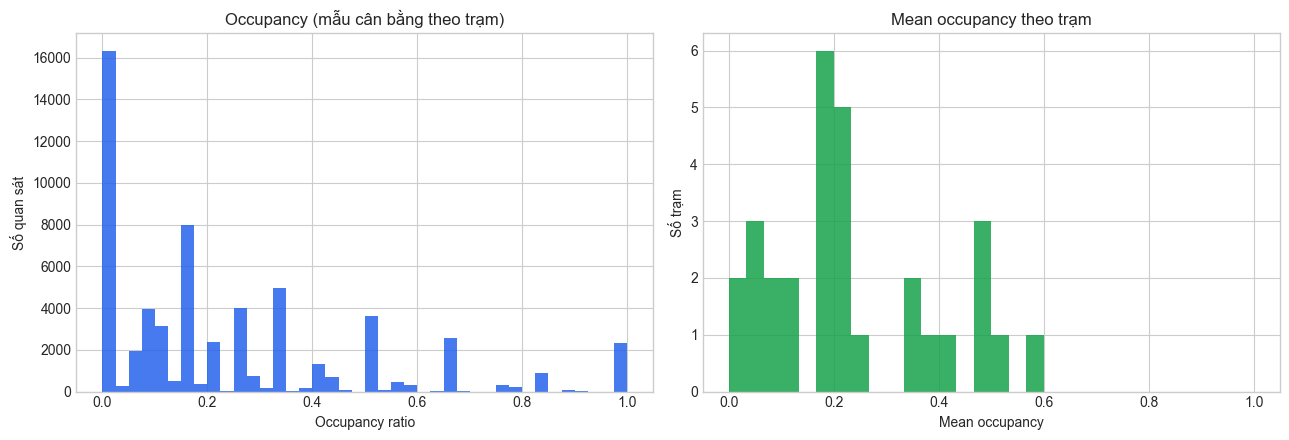

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(occupancy_sample["occupancy_ratio"], bins=40, range=(0, 1), color="#2563eb", alpha=0.85)
axes[0].set(title="Occupancy (mẫu cân bằng theo trạm)", xlabel="Occupancy ratio", ylabel="Số quan sát")
axes[1].hist(station_summary["occupancy_mean"].dropna(), bins=30, range=(0, 1), color="#16a34a", alpha=0.85)
axes[1].set(title="Mean occupancy theo trạm", xlabel="Mean occupancy", ylabel="Số trạm")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "occupancy_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

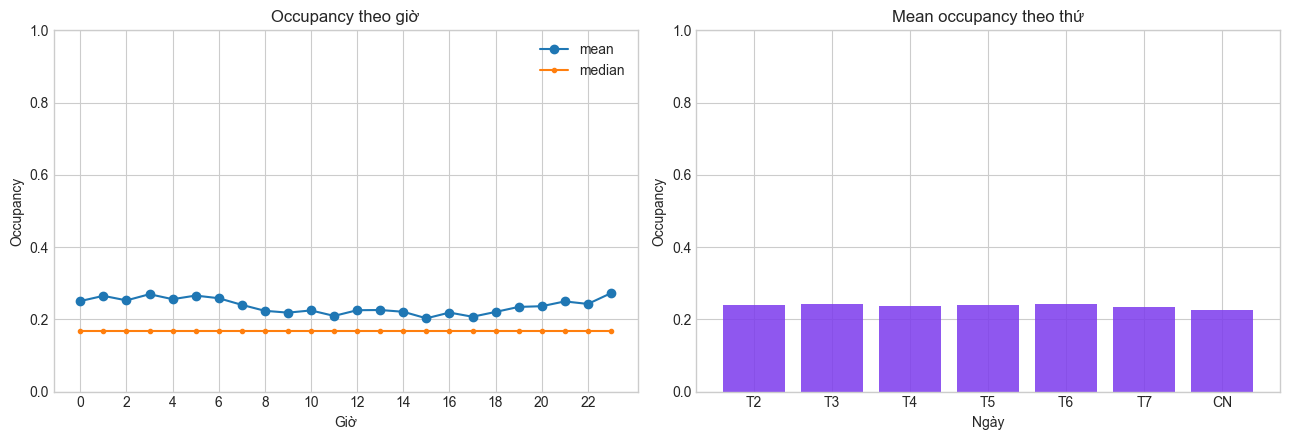

In [7]:
temporal_sample = occupancy_sample.dropna(subset=["time", "occupancy_ratio"]).copy()
temporal_sample["hour"] = temporal_sample["time"].dt.hour
temporal_sample["weekday"] = temporal_sample["time"].dt.dayofweek
hourly = temporal_sample.groupby("hour")["occupancy_ratio"].agg(["mean", "median"])
weekday = temporal_sample.groupby("weekday")["occupancy_ratio"].mean()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hourly.index, hourly["mean"], marker="o", label="mean")
axes[0].plot(hourly.index, hourly["median"], marker=".", label="median")
axes[0].set(title="Occupancy theo giờ", xlabel="Giờ", ylabel="Occupancy", xticks=range(0, 24, 2), ylim=(0, 1)); axes[0].legend()
axes[1].bar(weekday.index, weekday, color="#7c3aed", alpha=0.85)
axes[1].set(title="Mean occupancy theo thứ", xlabel="Ngày", ylabel="Occupancy", xticks=range(7), xticklabels=["T2", "T3", "T4", "T5", "T6", "T7", "CN"], ylim=(0, 1))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "temporal_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

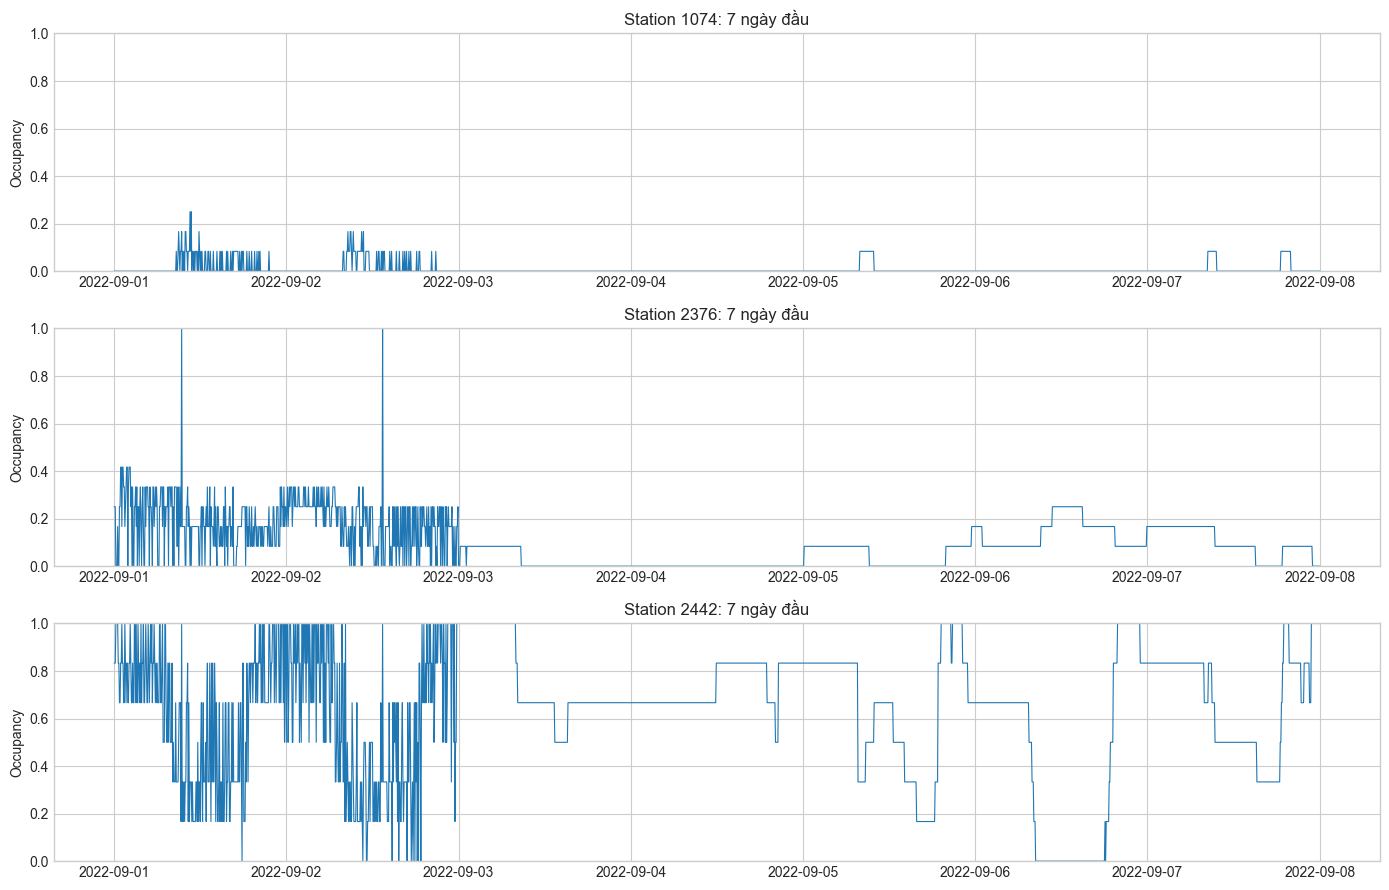

In [8]:
valid_rank = station_summary.dropna(subset=["occupancy_mean"]).sort_values("occupancy_mean")
representative_ids = []
for position in ((0, len(valid_rank) // 2, len(valid_rank) - 1) if len(valid_rank) else ()):
    station_id = str(valid_rank.iloc[position]["station_id"])
    if station_id not in representative_ids: representative_ids.append(station_id)
fig, axes = plt.subplots(len(representative_ids), 1, figsize=(14, 3 * max(1, len(representative_ids))))
axes = [axes] if len(representative_ids) == 1 else axes
with ZipFile(ARCHIVE) as archive:
    member_by_id = {Path(member).stem: member for member in selected_members}
    for axis, station_id in zip(axes, representative_ids):
        with archive.open(member_by_id[station_id]) as source:
            series = pd.read_csv(source, usecols=["time", "busy", "idle"])
        series["time"] = pd.to_datetime(series["time"], errors="coerce")
        series["occupancy_ratio"] = series["busy"] / (series["busy"] + series["idle"])
        start = series["time"].min()
        week = series[series["time"].between(start, start + pd.Timedelta(days=7))]
        axis.plot(week["time"], week["occupancy_ratio"], linewidth=0.8)
        axis.set(title=f"Station {station_id}: 7 ngày đầu", ylabel="Occupancy", ylim=(0, 1))
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "representative_station_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Xuất artifact

CSV phục vụ sort/filter thủ công. Manifest ghi mode và ngưỡng để tránh nhầm sample với full scan.

In [ ]:
summary_path = OUTPUT_DIR / "station_quality_summary.csv"
station_summary.sort_values(["suggested_review_status", "station_id"]).to_csv(summary_path, index=False)
run_manifest = {
    "mode": "full" if FULL_SCAN else "sample",
    "stations_available": len(station_members), "stations_scanned": len(station_summary),
    "random_seed": RANDOM_SEED, "expected_interval_min": EXPECTED_INTERVAL_MIN,
    "review_thresholds": {"max_missing_interval_rate": MAX_MISSING_INTERVAL_RATE, "min_occupancy_std": MIN_OCCUPANCY_STD},
    "important_limitations": [
        "Sample mode is not representative of the full dataset.",
        "Flags support manual review and are not automatic acceptance decisions.",
        "UrbanEV has no queue-length or wait-time ground truth.",
        "Shenzhen charging behavior must not be claimed as representative of Vietnam.",
    ],
}
manifest_path = OUTPUT_DIR / "eda_run_manifest.json"
manifest_path.write_text(json.dumps(run_manifest, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
print(f"Saved: {summary_path}")
print(f"Saved: {manifest_path}")
print(f"Figures: {OUTPUT_DIR}")

## 7. Manual decision gate

Chỉ chuyển sang preprocessing sau khi hoàn tất:

- [ ] Đã chạy `FULL_SCAN = True`; manifest ghi `mode = full`.
- [ ] Đã xem từng nhóm `review_flags`, không chỉ tổng PASS/REVIEW.
- [ ] Đã kiểm tra raw data của một số trạm đại diện trong mỗi nhóm lỗi.
- [ ] Đã quyết định cách xử lý timestamp thiếu/trùng, gap và capacity mismatch.
- [ ] Đã xác nhận target station-level occupancy ở interval 5 phút.
- [ ] Đã lập danh sách station ID được giữ và lý do loại.
- [ ] Đã ghi giới hạn: không có queue/wait ground truth và không suy rộng Shenzhen sang Việt Nam.
- [ ] Chưa dùng kết quả EDA để tự động ghi đè `station_status.json`.

**Quyết định:** `PROCEED / INVESTIGATE / STOP`  
**Người review:**  
**Ngày review:**  
**Ghi chú và station được chọn:**